In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    explained_variance_score,
    mean_absolute_percentage_error,
    median_absolute_error,
    max_error

)
pd.set_option("display.max_columns",None)
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from catboost import CatBoostRegressor

from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_regression
%matplotlib inline

2025-10-02 10:02:08.343461: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759399328.373545     555 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759399328.382633     555 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
df=pd.read_csv("/kaggle/input/playground-series-s5e9/train.csv")

In [3]:
df.head()

,id,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
0,0,0.603610,-7.636942,0.023500,0.000005,0.000001,0.051385,0.409866,290715.6450,0.826267,147.53020
1,1,0.639451,-16.267598,0.071520,0.444929,0.349414,0.170522,0.651010,164519.5174,0.145400,136.15963
2,2,0.514538,-15.953575,0.110715,0.173699,0.453814,0.029576,0.423865,174495.5667,0.624667,55.31989
3,3,0.734463,-1.357000,0.052965,0.001651,0.159717,0.086366,0.278745,225567.4651,0.487467,147.91212
4,4,0.532968,-13.056437,0.023500,0.068687,0.000001,0.331345,0.477769,213960.6789,0.947333,89.58511


In [4]:
df.shape

(524164, 11)

In [5]:
df.isnull().sum()

id                           0
RhythmScore                  0
AudioLoudness                0
VocalContent                 0
AcousticQuality              0
InstrumentalScore            0
LivePerformanceLikelihood    0
MoodScore                    0
TrackDurationMs              0
Energy                       0
BeatsPerMinute               0
dtype: int64

In [6]:
df.drop(columns=["id"],axis=1,inplace=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524164 entries, 0 to 524163
Data columns (total 10 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   RhythmScore                524164 non-null  float64
 1   AudioLoudness              524164 non-null  float64
 2   VocalContent               524164 non-null  float64
 3   AcousticQuality            524164 non-null  float64
 4   InstrumentalScore          524164 non-null  float64
 5   LivePerformanceLikelihood  524164 non-null  float64
 6   MoodScore                  524164 non-null  float64
 7   TrackDurationMs            524164 non-null  float64
 8   Energy                     524164 non-null  float64
 9   BeatsPerMinute             524164 non-null  float64
dtypes: float64(10)
memory usage: 40.0 MB


In [8]:
df.describe()

,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
count,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000
mean,0.632843,-8.379014,0.074443,0.262913,0.117690,0.178398,0.555843,241903.692949,0.500923,119.034899
std,0.156899,4.616221,0.049939,0.223120,0.131845,0.118186,0.225480,59326.601501,0.289952,26.468077
min,0.076900,-27.509725,0.023500,0.000005,0.000001,0.024300,0.025600,63973.000000,0.000067,46.718000
25%,0.515850,-11.551933,0.023500,0.069413,0.000001,0.077637,0.403921,207099.876625,0.254933,101.070410
50%,0.634686,-8.252499,0.066425,0.242502,0.074247,0.166327,0.564817,243684.058150,0.511800,118.747660
75%,0.739179,-4.912298,0.107343,0.396957,0.204065,0.268946,0.716633,281851.658500,0.746000,136.686590
max,0.975000,-1.357000,0.256401,0.995000,0.869258,0.599924,0.978000,464723.228100,1.000000,206.037000


In [9]:
df.head()

,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
0,0.603610,-7.636942,0.023500,0.000005,0.000001,0.051385,0.409866,290715.6450,0.826267,147.53020
1,0.639451,-16.267598,0.071520,0.444929,0.349414,0.170522,0.651010,164519.5174,0.145400,136.15963
2,0.514538,-15.953575,0.110715,0.173699,0.453814,0.029576,0.423865,174495.5667,0.624667,55.31989
3,0.734463,-1.357000,0.052965,0.001651,0.159717,0.086366,0.278745,225567.4651,0.487467,147.91212
4,0.532968,-13.056437,0.023500,0.068687,0.000001,0.331345,0.477769,213960.6789,0.947333,89.58511


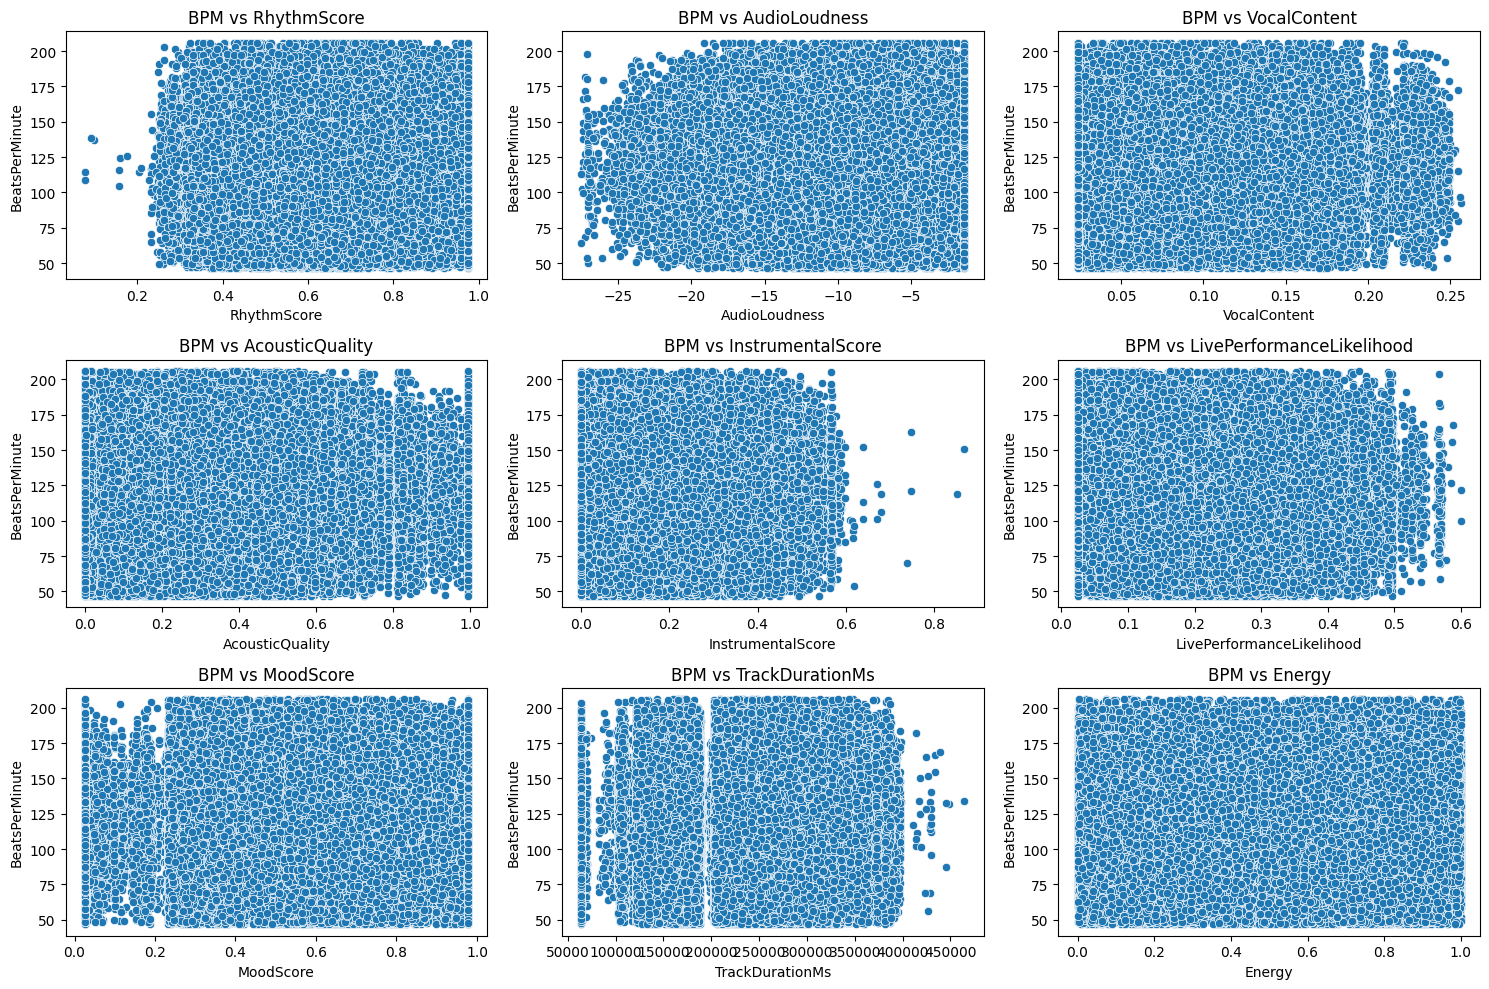

In [10]:
features = df.columns.drop('BeatsPerMinute')
plt.figure(figsize=(15, 10))
for i, feature in enumerate(features, 1):
    plt.subplot(3, 3, i)
    sns.scatterplot(x=feature, y='BeatsPerMinute', data=df)
    plt.title(f'BPM vs {feature}')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


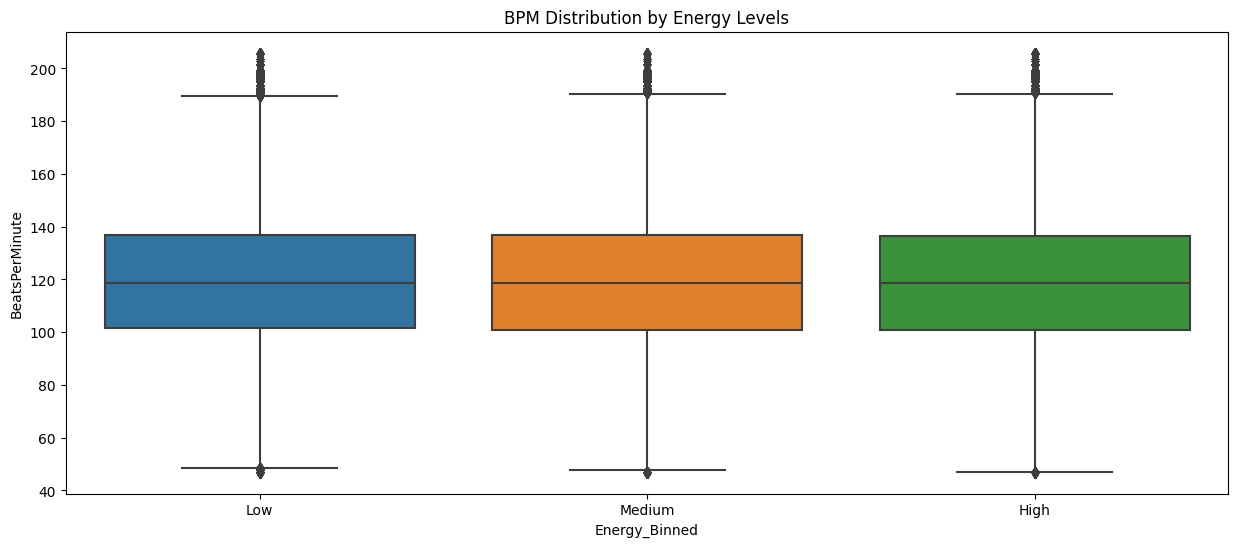

In [11]:
df['Energy_Binned'] = pd.qcut(df['Energy'], q=3, labels=['Low', 'Medium', 'High'])
plt.figure(figsize=(15, 6))
sns.boxplot(x='Energy_Binned', y='BeatsPerMinute', data=df)
plt.title('BPM Distribution by Energy Levels')
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


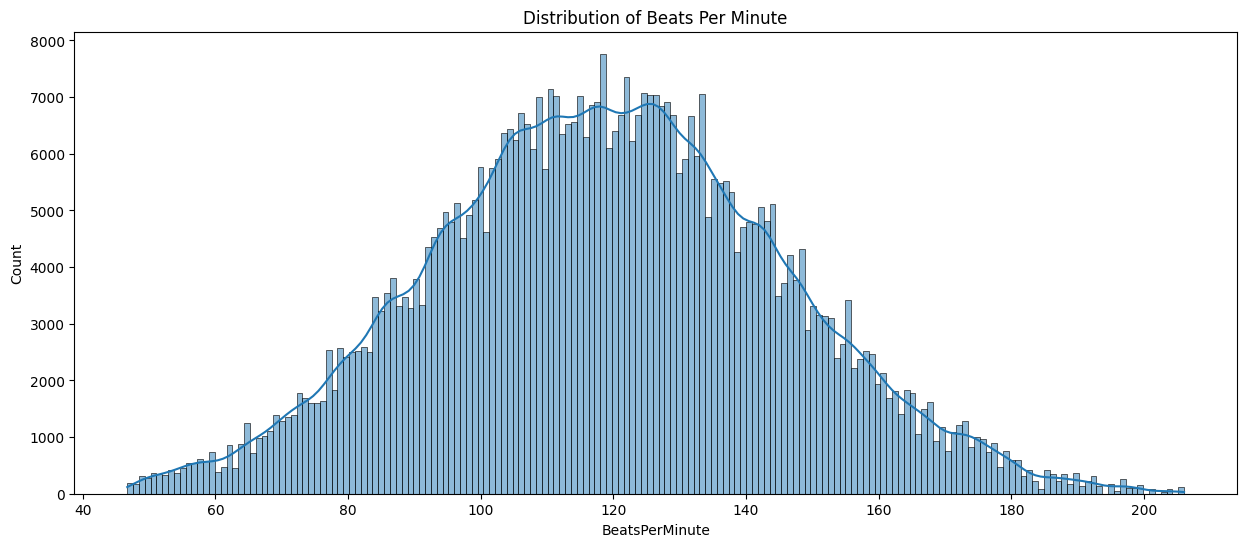

In [12]:
plt.figure(figsize=(15, 6))
sns.histplot(df['BeatsPerMinute'], kde=True)
plt.title('Distribution of Beats Per Minute')
plt.show()

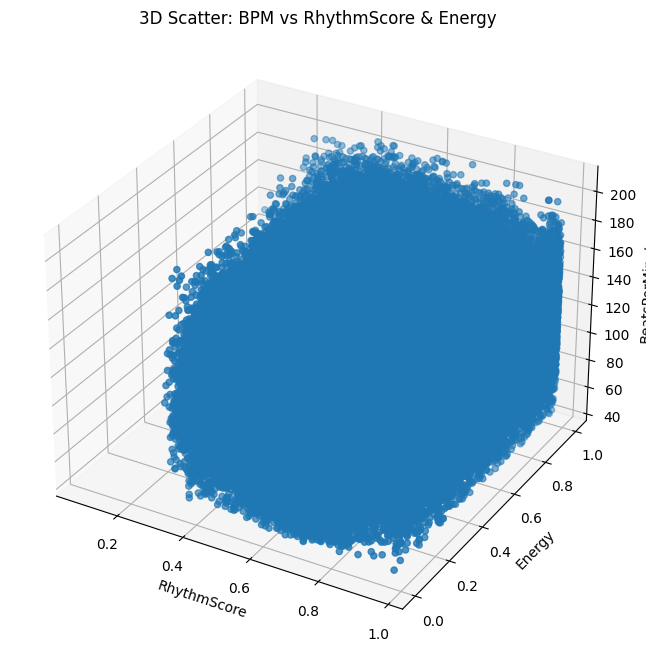

In [13]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(15, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['RhythmScore'], df['Energy'], df['BeatsPerMinute'])
ax.set_xlabel('RhythmScore')
ax.set_ylabel('Energy')
ax.set_zlabel('BeatsPerMinute')
plt.title('3D Scatter: BPM vs RhythmScore & Energy')
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


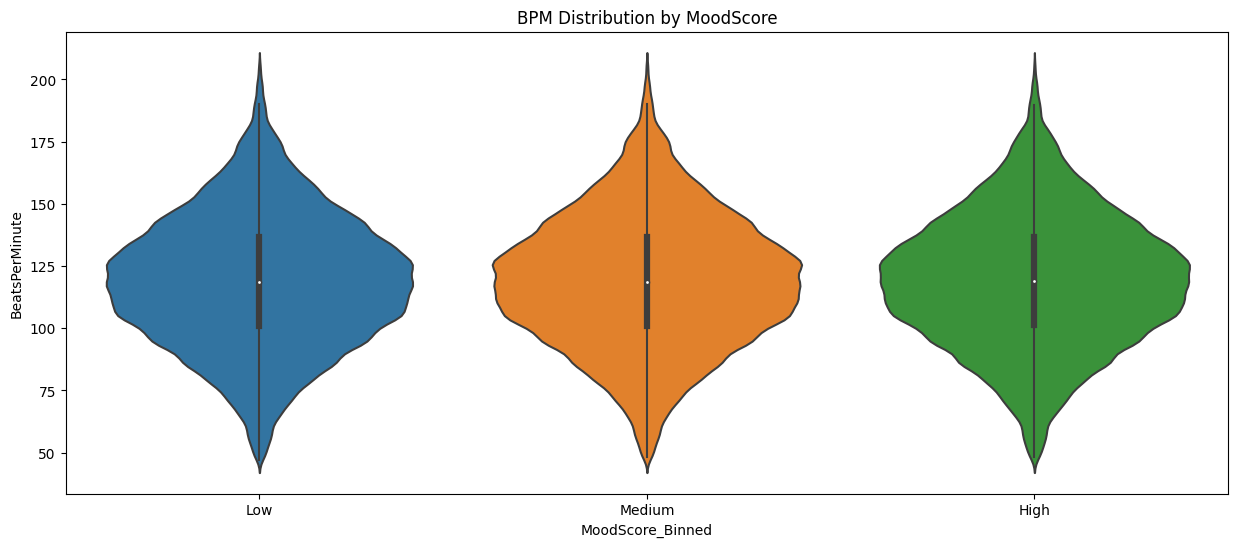

In [14]:
df['MoodScore_Binned'] = pd.qcut(df['MoodScore'], q=3, labels=['Low', 'Medium', 'High'])
plt.figure(figsize=(15, 6))
sns.violinplot(x='MoodScore_Binned', y='BeatsPerMinute', data=df)
plt.title('BPM Distribution by MoodScore')
plt.show()

In [15]:
df.drop(columns=["Energy_Binned","MoodScore_Binned"],axis=1,inplace=True)

In [16]:
from sklearn.model_selection import train_test_split

# Features and target
X = df.drop("BeatsPerMinute", axis=1)   # replace with your real target column
y = df["BeatsPerMinute"]

In [17]:
X['Log_TrackDurationMs'] = np.log1p(X['TrackDurationMs'])
X['Log_AudioLoudness'] = np.log1p(-X['AudioLoudness'])  

In [18]:
X.drop(columns=["TrackDurationMs","AudioLoudness"],axis=1,inplace=True)

In [19]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

In [20]:
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_poly = poly.fit_transform(X_scaled)
poly_columns = poly.get_feature_names_out(X.columns)
X_poly = pd.DataFrame(X_poly, columns=poly_columns)
y_capped = np.clip(y, y.quantile(0.01), y.quantile(0.99))

In [21]:
X_poly.shape

(524164, 45)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X_poly, y_capped, test_size=0.2, random_state=42)


In [23]:
cat_model = CatBoostRegressor(iterations=1000,learning_rate=0.005,depth=6,loss_function='RMSE',random_state=42,verbose=200)

cat_model.fit(X_train, y_train)

0:	learn: 26.1334880	total: 132ms	remaining: 2m 11s
200:	learn: 26.1218208	total: 12.1s	remaining: 48.2s
400:	learn: 26.1149737	total: 24.1s	remaining: 36s
600:	learn: 26.1090807	total: 35.8s	remaining: 23.8s
800:	learn: 26.1033262	total: 47.4s	remaining: 11.8s
999:	learn: 26.0978202	total: 58.7s	remaining: 0us


In [24]:
# Predictions
y_pred = cat_model.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)  # same as np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
evs = explained_variance_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
medae = median_absolute_error(y_test, y_pred)
maxerr = max_error(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2 Score: {r2:.4f}")
print(f"Explained Variance: {evs:.4f}")
print(f"MAPE: {mape:.4f}")
print(f"Median AE: {medae:.4f}")
print(f"Max Error: {maxerr:.4f}")


MSE: 681.6746
RMSE: 26.1089
MAE: 21.0508
R2 Score: 0.0004
Explained Variance: 0.0004
MAPE: 0.1956
Median AE: 17.8263
Max Error: 64.8594


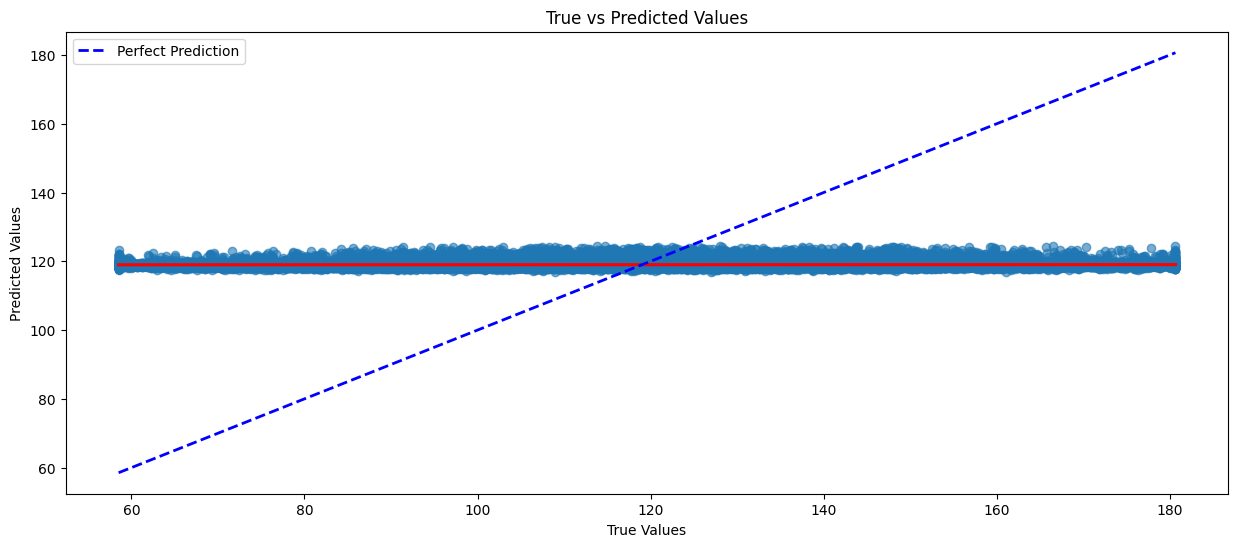

In [25]:
plt.figure(figsize=(15, 6))
sns.regplot(x=y_test, y=y_pred, line_kws={"color": "red"}, scatter_kws={"alpha": 0.6})

# Reference line (perfect predictions)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],color='blue', linestyle='--', linewidth=2, label="Perfect Prediction")

plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("True vs Predicted Values")
plt.legend()
plt.show()

In [26]:
test_df=pd.read_csv("/kaggle/input/playground-series-s5e9/test.csv")

In [27]:
test_df.head()

,id,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy
0,524164,0.410013,-16.794967,0.023500,0.232910,0.012689,0.271585,0.664321,302901.5498,0.424867
1,524165,0.463071,-1.357000,0.141818,0.057725,0.257942,0.097624,0.829552,221995.6643,0.846000
2,524166,0.686569,-3.368928,0.167851,0.287823,0.210915,0.325909,0.304978,357724.0127,0.134067
3,524167,0.885793,-5.598049,0.118488,0.000005,0.376906,0.134435,0.487740,271790.3989,0.316467
4,524168,0.637391,-7.068160,0.126099,0.539073,0.068950,0.024300,0.591248,277728.5383,0.481067


In [28]:
Id=test_df.id

In [29]:
test_df.drop(columns=["id"],axis=1,inplace=True)

In [30]:
test_df.isnull().sum()

RhythmScore                  0
AudioLoudness                0
VocalContent                 0
AcousticQuality              0
InstrumentalScore            0
LivePerformanceLikelihood    0
MoodScore                    0
TrackDurationMs              0
Energy                       0
dtype: int64

In [31]:
test_df['Log_TrackDurationMs'] = np.log1p(test_df['TrackDurationMs'])
test_df['Log_AudioLoudness'] = np.log1p(-test_df['AudioLoudness'])
test_df.drop(columns=["TrackDurationMs", "AudioLoudness"], axis=1, inplace=True)
test_df = test_df[X_scaled.columns]
test_scaled = scaler.transform(test_df)
test_df_scaled = pd.DataFrame(test_scaled, columns=X_scaled.columns)
test_poly = poly.transform(test_df_scaled)
poly_columns = poly.get_feature_names_out(X_scaled.columns)
test_df = pd.DataFrame(test_poly, columns=poly_columns)

In [32]:
test_df.shape

(174722, 45)

In [33]:
y_pred=cat_model.predict(test_df)
df=pd.DataFrame({"id":Id,"BeatsPerMinute":y_pred})
df.to_csv("submission.csv",index=False)

In [34]:
df.head()

,id,BeatsPerMinute
0,524164,118.951450
1,524165,119.090727
2,524166,119.020785
3,524167,119.288638
4,524168,119.371647
